# Identificação de Ativos IoT em Redes Corporativas utilizando Redes Neurais Artificiais

## Disciplina
Redes Neurais em Segurança Cibernética  
PPEE – Universidade de Brasília (UnB)
Professor: Dr. André Serrano
Aluno: Leonardo Santiago Melgaço Silva
Matricula PPEE: 252110506

## Tema
Controle 1 – Inventário e Controle de Ativos Corporativos

## Objetivo

Desenvolver uma aplicação de Redes Neurais Artificiais capaz de
identificar e classificar dispositivos IoT a partir de características
extraídas do tráfego de rede.

A aplicação busca demonstrar como técnicas de aprendizado de máquina
podem apoiar o processo de descoberta e identificação de ativos em uma
rede corporativa.

### Relação com Segurança Cibernética

O Controle 1 do CIS Controls estabelece a necessidade de conhecer,
inventariar e acompanhar os ativos existentes na infraestrutura.

Neste projeto, características observáveis do tráfego de rede são
utilizadas como uma forma de fingerprinting comportamental para
classificar o tipo de dispositivo IoT.

O resultado pode ser utilizado como mecanismo auxiliar para:

- descoberta de ativos;
- identificação de dispositivos;
- atualização do inventário;
- identificação de dispositivos desconhecidos;
- apoio à identificação de possíveis ativos não autorizados.

**Observação:** a classificação realizada pela rede neural não substitui
o processo formal de inventário e autorização de ativos. Ela constitui
um mecanismo de apoio à descoberta e classificação.

In [1]:
# ============================================================
# INSTALAÇÃO DAS BIBLIOTECAS
# ============================================================

!pip -q install kaggle pandas numpy matplotlib seaborn scikit-learn tensorflow

In [2]:
# ============================================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================

import os
import glob
import zipfile
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", __import__("sklearn").__version__)

TensorFlow: 2.20.0
NumPy: 2.1.3
Pandas: 2.2.3
Scikit-learn: 1.6.1


In [3]:
# ============================================================
# CONFIGURAÇÃO DE REPRODUTIBILIDADE
# ============================================================

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"Seed definida: {SEED}")

Seed definida: 42


In [4]:
# ============================================================
# DOWNLOAD DO DATASET
# ============================================================

!wget -q -O iot-device-identification.zip \
"https://www.kaggle.com/api/v1/datasets/download/fanbyprinciple/iot-device-identification"

print("Download concluído.")

Download concluído.


In [5]:
# ============================================================
# DESCOMPACTAÇÃO
# ============================================================

DATASET_DIR = "/content/iot_dataset"

os.makedirs(DATASET_DIR, exist_ok=True)

zip_path = "/content/iot-device-identification.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(DATASET_DIR)

print("Dataset descompactado em:")
print(DATASET_DIR)

Dataset descompactado em:
/content/iot_dataset


In [6]:
# ============================================================
# LISTAGEM DOS ARQUIVOS
# ============================================================

files = []

for root, dirs, filenames in os.walk(DATASET_DIR):
    for filename in filenames:
        files.append(os.path.join(root, filename))

print("Arquivos encontrados:")
print("-" * 60)

for file in files:
    print(file)

Arquivos encontrados:
------------------------------------------------------------
/content/iot_dataset/iot_device_train.csv
/content/iot_dataset/iot_device_test.csv


In [7]:
# ============================================================
# IDENTIFICAÇÃO DOS ARQUIVOS CSV
# ============================================================

csv_files = glob.glob(
    os.path.join(DATASET_DIR, "**", "*.csv"),
    recursive=True
)

print(f"Quantidade de arquivos CSV encontrados: {len(csv_files)}")
print()

for i, file in enumerate(csv_files):
    print(f"[{i}] {file}")

Quantidade de arquivos CSV encontrados: 2

[0] /content/iot_dataset/iot_device_train.csv
[1] /content/iot_dataset/iot_device_test.csv


In [8]:
# ============================================================
# CARREGAMENTO DOS CSVs
# ============================================================

dataframes = {}

for file in csv_files:

    filename = os.path.basename(file)

    try:
        df_temp = pd.read_csv(file)
        dataframes[filename] = df_temp

        print("=" * 70)
        print(f"Arquivo: {filename}")
        print(f"Linhas: {df_temp.shape[0]}")
        print(f"Colunas: {df_temp.shape[1]}")

    except Exception as e:
        print(f"Erro ao carregar {filename}: {e}")

Arquivo: iot_device_train.csv
Linhas: 1000
Colunas: 298
Arquivo: iot_device_test.csv
Linhas: 900
Colunas: 298


In [9]:
# ============================================================
# VISUALIZAÇÃO INICIAL
# ============================================================

for filename, df_temp in dataframes.items():

    print("=" * 80)
    print(f"ARQUIVO: {filename}")
    print("=" * 80)

    display(df_temp.head())

ARQUIVO: iot_device_train.csv


,ack,ack_A,ack_B,bytes,bytes_A,bytes_A_B_ratio,bytes_B,ds_field_A,ds_field_B,duration,...,suffix_is_co.il,suffix_is_com,suffix_is_com.sg,suffix_is_else,suffix_is_empty_char_value,suffix_is_googleapis.com,suffix_is_net,suffix_is_org,suffix_is_unresolved,device_category
0,9,5,5,1213,743,0.713924,668,0,0,1.5756,...,0,0,0,1,0,0,0,0,0,security_camera
1,9,5,5,1213,743,1.806874,668,0,0,0.6890,...,0,0,0,1,0,0,0,0,0,security_camera
2,9,5,5,1213,743,0.103124,668,0,0,0.9852,...,0,0,0,1,0,0,0,0,0,security_camera
3,9,5,5,1213,743,1.806874,668,0,0,1.5756,...,0,0,0,1,0,0,0,0,0,security_camera
4,9,5,5,1213,743,1.806874,668,0,0,1.5756,...,0,0,0,1,0,0,0,0,0,security_camera


ARQUIVO: iot_device_test.csv


,ack,ack_A,ack_B,bytes,bytes_A,bytes_A_B_ratio,bytes_B,ds_field_A,ds_field_B,duration,...,suffix_is_co.il,suffix_is_com,suffix_is_com.sg,suffix_is_else,suffix_is_empty_char_value,suffix_is_googleapis.com,suffix_is_net,suffix_is_org,suffix_is_unresolved,device_category
0,38,20,18,14698,7814,1.135096,6884,0,0,1.9156,...,0,0,0,1,0,0,0,0,0,baby_monitor
1,38,20,18,14698,7814,1.135096,6884,0,0,2.0020,...,0,0,0,1,0,0,0,0,0,baby_monitor
2,38,20,18,14762,7814,1.124640,6948,0,0,2.1833,...,0,0,0,1,0,0,0,0,0,baby_monitor
3,38,20,18,14762,7814,1.124640,6948,0,0,2.1521,...,0,0,0,1,0,0,0,0,0,baby_monitor
4,41,20,21,14862,7994,1.163949,6868,0,0,2.2422,...,0,0,0,1,0,0,0,0,0,baby_monitor


In [10]:
# ============================================================
# DIMENSÕES
# ============================================================

for filename, df_temp in dataframes.items():

    print(
        f"{filename:40s} "
        f"→ {df_temp.shape[0]} linhas × {df_temp.shape[1]} colunas"
    )

iot_device_train.csv                     → 1000 linhas × 298 colunas
iot_device_test.csv                      → 900 linhas × 298 colunas


In [11]:
# ============================================================
# NOMES DAS COLUNAS
# ============================================================

for filename, df_temp in dataframes.items():

    print("\n")
    print("=" * 80)
    print(f"COLUNAS: {filename}")
    print("=" * 80)

    for i, column in enumerate(df_temp.columns):
        print(f"{i:3d} → {column}")



COLUNAS: iot_device_train.csv
  0 → ack
  1 → ack_A
  2 → ack_B
  3 → bytes
  4 → bytes_A
  5 → bytes_A_B_ratio
  6 → bytes_B
  7 → ds_field_A
  8 → ds_field_B
  9 → duration
 10 → http_GET
 11 → http_POST
 12 → http_bytes_avg
 13 → http_bytes_entropy
 14 → http_bytes_firstQ
 15 → http_bytes_max
 16 → http_bytes_median
 17 → http_bytes_min
 18 → http_bytes_stdev
 19 → http_bytes_sum
 20 → http_bytes_thirdQ
 21 → http_bytes_var
 22 → http_cookie_count
 23 → http_cookie_values_avg
 24 → http_cookie_values_entropy
 25 → http_cookie_values_firstQ
 26 → http_cookie_values_max
 27 → http_cookie_values_median
 28 → http_cookie_values_min
 29 → http_cookie_values_stdev
 30 → http_cookie_values_sum
 31 → http_cookie_values_thirdQ
 32 → http_cookie_values_var
 33 → http_count_host
 34 → http_count_req_content_type
 35 → http_count_resp_code
 36 → http_count_resp_content_type
 37 → http_count_transactions
 38 → http_count_user_agents
 39 → http_dom_host_alexaRank
 40 → http_dom_resp_code
 41 → 

In [12]:
# ============================================================
# TIPOS DAS VARIÁVEIS
# ============================================================

for filename, df_temp in dataframes.items():

    print("=" * 80)
    print(f"TIPOS DAS VARIÁVEIS: {filename}")
    print("=" * 80)

    display(
        df_temp.dtypes
        .value_counts()
        .rename_axis("Tipo")
        .reset_index(name="Quantidade")
    )

TIPOS DAS VARIÁVEIS: iot_device_train.csv


,Tipo,Quantidade
0,int64,217
1,float64,80
2,object,1


TIPOS DAS VARIÁVEIS: iot_device_test.csv


,Tipo,Quantidade
0,int64,174
1,float64,123
2,object,1


In [13]:
# ============================================================
# VALORES AUSENTES
# ============================================================

for filename, df_temp in dataframes.items():

    missing = df_temp.isnull().sum()

    missing = missing[missing > 0].sort_values(ascending=False)

    print("=" * 80)
    print(f"VALORES AUSENTES: {filename}")
    print("=" * 80)

    if len(missing) == 0:
        print("Nenhum valor ausente encontrado.")
    else:
        display(missing.to_frame("Valores ausentes"))

VALORES AUSENTES: iot_device_train.csv
Nenhum valor ausente encontrado.
VALORES AUSENTES: iot_device_test.csv
Nenhum valor ausente encontrado.


In [14]:
# ============================================================
# COLUNAS CATEGÓRICAS
# ============================================================

for filename, df_temp in dataframes.items():

    categorical_columns = df_temp.select_dtypes(
        include=["object", "category"]
    ).columns

    print("=" * 80)
    print(f"VARIÁVEIS CATEGÓRICAS: {filename}")
    print("=" * 80)

    for column in categorical_columns:
        print(
            f"{column:40s} "
            f"→ {df_temp[column].nunique()} valores únicos"
        )

VARIÁVEIS CATEGÓRICAS: iot_device_train.csv
device_category                          → 10 valores únicos
VARIÁVEIS CATEGÓRICAS: iot_device_test.csv
device_category                          → 9 valores únicos


In [15]:
# ============================================================
# VALORES DAS VARIÁVEIS CATEGÓRICAS
# ============================================================

for filename, df_temp in dataframes.items():

    categorical_columns = df_temp.select_dtypes(
        include=["object", "category"]
    ).columns

    print("=" * 80)
    print(filename)
    print("=" * 80)

    for column in categorical_columns:

        print(f"\nColuna: {column}")
        print(
            df_temp[column]
            .value_counts(dropna=False)
            .head(30)
        )

iot_device_train.csv

Coluna: device_category
device_category
security_camera    100
TV                 100
smoke_detector     100
thermostat         100
water_sensor       100
watch              100
baby_monitor       100
motion_sensor      100
lights             100
socket             100
Name: count, dtype: int64
iot_device_test.csv

Coluna: device_category
device_category
baby_monitor       100
lights             100
motion_sensor      100
security_camera    100
smoke_detector     100
socket             100
thermostat         100
TV                 100
watch              100
Name: count, dtype: int64


In [16]:
# ============================================================
# POSSÍVEIS VARIÁVEIS-ALVO
# ============================================================

keywords = [
    "device",
    "device_category",
    "category",
    "class",
    "target",
    "type",
    "label"
]

for filename, df_temp in dataframes.items():

    print("=" * 80)
    print(f"POSSÍVEIS TARGETS: {filename}")
    print("=" * 80)

    for column in df_temp.columns:

        column_lower = column.lower()

        if any(keyword in column_lower for keyword in keywords):

            print(
                f"{column:40s} "
                f"→ {df_temp[column].nunique()} valores únicos"
            )

POSSÍVEIS TARGETS: iot_device_train.csv
http_count_req_content_type              → 2 valores únicos
http_count_resp_content_type             → 2 valores únicos
http_has_req_content_type                → 2 valores únicos
http_has_resp_content_type               → 2 valores únicos
device_category                          → 10 valores únicos
POSSÍVEIS TARGETS: iot_device_test.csv
http_count_req_content_type              → 2 valores únicos
http_count_resp_content_type             → 3 valores únicos
http_has_req_content_type                → 2 valores únicos
http_has_resp_content_type               → 2 valores únicos
device_category                          → 9 valores únicos


In [17]:
# ============================================================
# LOCALIZAÇÃO DO DATASET DE TREINAMENTO
# ============================================================

train_candidates = [
    file for file in csv_files
    if "train" in os.path.basename(file).lower()
]

print("Possíveis arquivos de treinamento:")

for file in train_candidates:
    print(file)

Possíveis arquivos de treinamento:
/content/iot_dataset/iot_device_train.csv


In [18]:
# ============================================================
# SELEÇÃO DO DATASET PRINCIPAL
# ============================================================

if len(train_candidates) == 0:
    raise FileNotFoundError(
        "Nenhum arquivo contendo 'train' foi encontrado."
    )

TRAIN_FILE = train_candidates[0]

df = pd.read_csv(TRAIN_FILE)

print("Arquivo selecionado:")
print(TRAIN_FILE)

print()
print("Dimensões:")
print(df.shape)

Arquivo selecionado:
/content/iot_dataset/iot_device_train.csv

Dimensões:
(1000, 298)


In [19]:
# ============================================================
# INSPEÇÃO DO DATASET PRINCIPAL
# ============================================================

print("=" * 80)
print("INFORMAÇÕES DO DATASET")
print("=" * 80)

print(f"Número de observações: {df.shape[0]}")
print(f"Número de atributos:   {df.shape[1]}")

print("\nPrimeiras linhas:")
display(df.head())

print("\nInformações:")
df.info()

INFORMAÇÕES DO DATASET
Número de observações: 1000
Número de atributos:   298

Primeiras linhas:


,ack,ack_A,ack_B,bytes,bytes_A,bytes_A_B_ratio,bytes_B,ds_field_A,ds_field_B,duration,...,suffix_is_co.il,suffix_is_com,suffix_is_com.sg,suffix_is_else,suffix_is_empty_char_value,suffix_is_googleapis.com,suffix_is_net,suffix_is_org,suffix_is_unresolved,device_category
0,9,5,5,1213,743,0.713924,668,0,0,1.5756,...,0,0,0,1,0,0,0,0,0,security_camera
1,9,5,5,1213,743,1.806874,668,0,0,0.6890,...,0,0,0,1,0,0,0,0,0,security_camera
2,9,5,5,1213,743,0.103124,668,0,0,0.9852,...,0,0,0,1,0,0,0,0,0,security_camera
3,9,5,5,1213,743,1.806874,668,0,0,1.5756,...,0,0,0,1,0,0,0,0,0,security_camera
4,9,5,5,1213,743,1.806874,668,0,0,1.5756,...,0,0,0,1,0,0,0,0,0,security_camera



Informações:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Columns: 298 entries, ack to device_category
dtypes: float64(80), int64(217), object(1)
memory usage: 2.3+ MB


Identificar a variável de dispositivo

Agora vamos procurar especificamente device_category, que é a variável documentada em trabalhos que utilizaram esse dataset. A literatura identifica dez categorias no treinamento, incluindo baby_monitor, lights, motion_sensor, security_camera, smoke_detector, socket, thermostat, TV, watch e water_sensor.

In [20]:
# ============================================================
# IDENTIFICAÇÃO DA VARIÁVEL DE DISPOSITIVO
# ============================================================

possible_targets = [
    "device_category",
    "device",
    "device_type",
    "category",
    "class"
]

TARGET = None

for candidate in possible_targets:

    matching_columns = [
        col for col in df.columns
        if col.lower() == candidate.lower()
    ]

    if matching_columns:
        TARGET = matching_columns[0]
        break

if TARGET is None:
    print("Não foi possível identificar automaticamente o target.")
    print("Colunas candidatas:")

    for col in df.columns:
        if any(
            word in col.lower()
            for word in ["device", "category", "class", "type"]
        ):
            print(col)
else:
    print(f"Variável-alvo identificada: {TARGET}")

Variável-alvo identificada: device_category


In [21]:
# ============================================================
# CONFIRMAÇÃO DO TARGET
# ============================================================

if TARGET is None:
    raise ValueError(
        "TARGET não identificado. "
        "Execute a célula anterior e defina manualmente a variável."
    )

print("Variável utilizada como TARGET:")
print(TARGET)

print("\nClasses encontradas:")
print(df[TARGET].unique())

print(
    f"\nQuantidade de classes: "
    f"{df[TARGET].nunique()}"
)

Variável utilizada como TARGET:
device_category

Classes encontradas:
['security_camera' 'TV' 'smoke_detector' 'thermostat' 'water_sensor'
 'watch' 'baby_monitor' 'motion_sensor' 'lights' 'socket']

Quantidade de classes: 10


,Quantidade
device_category,
security_camera,100
TV,100
smoke_detector,100
thermostat,100
water_sensor,100
watch,100
baby_monitor,100
motion_sensor,100
lights,100


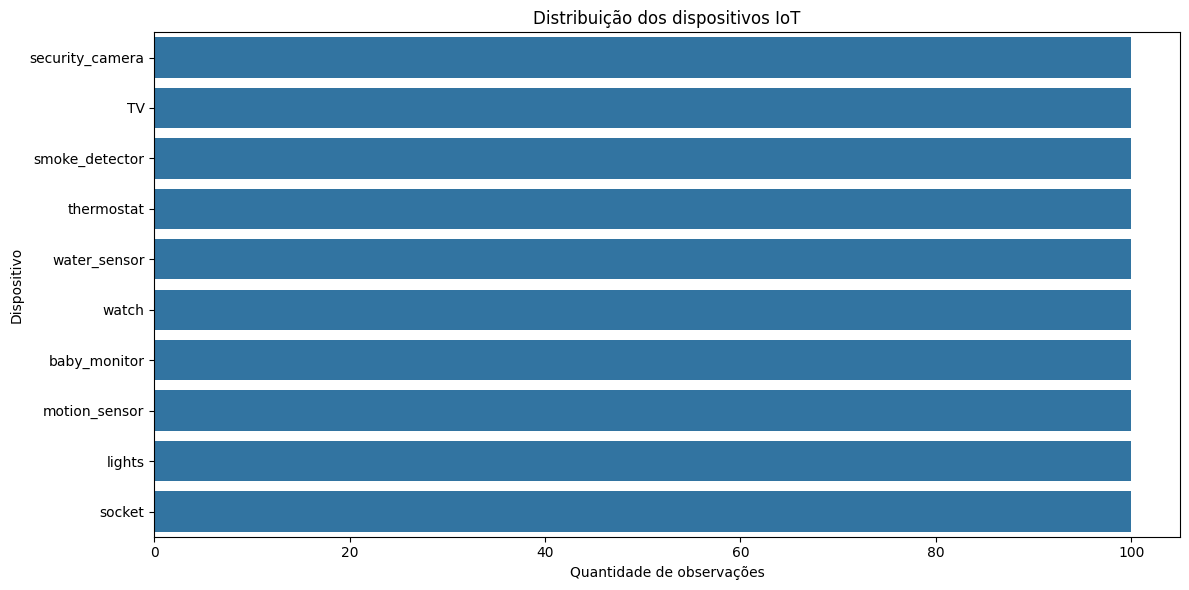

In [22]:
# ============================================================
# DISTRIBUIÇÃO DAS CLASSES
# ============================================================

class_counts = (
    df[TARGET]
    .value_counts()
    .sort_values(ascending=False)
)

display(class_counts.to_frame("Quantidade"))

plt.figure(figsize=(12, 6))

sns.barplot(
    x=class_counts.values,
    y=class_counts.index
)

plt.title("Distribuição dos dispositivos IoT")
plt.xlabel("Quantidade de observações")
plt.ylabel("Dispositivo")

plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# PERCENTUAL DAS CLASSES
# ============================================================

class_percentage = (
    df[TARGET]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(
    class_percentage
    .to_frame("Percentual (%)")
)

,Percentual (%)
device_category,
security_camera,10.0
TV,10.0
smoke_detector,10.0
thermostat,10.0
water_sensor,10.0
watch,10.0
baby_monitor,10.0
motion_sensor,10.0
lights,10.0


In [24]:
# ============================================================
# SEPARAÇÃO ENTRE FEATURES E TARGET
# ============================================================

X = df.drop(columns=[TARGET]).copy()

y = df[TARGET].copy()

print("Dimensões de X:")
print(X.shape)

print("\nDimensões de y:")
print(y.shape)

print("\nTarget:")
print(y.head())

Dimensões de X:
(1000, 297)

Dimensões de y:
(1000,)

Target:
0    security_camera
1    security_camera
2    security_camera
3    security_camera
4    security_camera
Name: device_category, dtype: object


Remover identificadores inadequados

Aqui precisamos ter cuidado.

Endereço IP, MAC, identificadores específicos etc. podem fazer a rede neural decorar o dispositivo, em vez de aprender seu comportamento de tráfego.

Por isso, vamos investigar primeiro.

In [25]:
# ============================================================
# IDENTIFICAÇÃO DE POSSÍVEIS IDENTIFICADORES
# ============================================================

identifier_keywords = [
    "ip",
    "mac",
    "address",
    "id",
    "identifier"
]

possible_identifiers = []

for column in X.columns:

    column_lower = column.lower()

    if any(
        keyword in column_lower
        for keyword in identifier_keywords
    ):
        possible_identifiers.append(column)

print("Possíveis identificadores:")
print("-" * 60)

for column in possible_identifiers:
    print(column)

Possíveis identificadores:
------------------------------------------------------------
ssl_count_client_cipher_algs
ssl_count_client_ciphersuites
ssl_count_client_elliptic_curves
ssl_count_client_mac_algs
ssl_count_server_ciphersuite
ssl_count_server_elliptic_curve
ssl_dom_server_ciphersuite
ssl_ratio_client_elliptic_curves


In [26]:
# ============================================================
# ANÁLISE DE CARDINALIDADE
# ============================================================

cardinality = pd.DataFrame({
    "coluna": X.columns,
    "valores_unicos": [
        X[col].nunique(dropna=False)
        for col in X.columns
    ]
})

cardinality = cardinality.sort_values(
    "valores_unicos",
    ascending=False
)

display(cardinality.head(30))

,coluna,valores_unicos
113,packet_inter_arrivel_sum,978
106,packet_inter_arrivel_avg,978
112,packet_inter_arrivel_stdev,975
115,packet_inter_arrivel_var,975
109,packet_inter_arrivel_max,973
93,packet_inter_arrivel_A_sum,973
86,packet_inter_arrivel_A_avg,973
92,packet_inter_arrivel_A_stdev,970
95,packet_inter_arrivel_A_var,970
89,packet_inter_arrivel_A_max,969


Remover colunas constantes

Essa remoção é segura e justificada: uma variável que possui apenas um valor não traz informação para classificação.

In [27]:
# ============================================================
# REMOÇÃO DE FEATURES CONSTANTES
# ============================================================

constant_columns = [
    col for col in X.columns
    if X[col].nunique(dropna=False) <= 1
]

print(
    f"Quantidade de features constantes: "
    f"{len(constant_columns)}"
)

if len(constant_columns) > 0:
    print("\nFeatures removidas:")
    print(constant_columns)

    X = X.drop(columns=constant_columns)

print("\nNova dimensão de X:")
print(X.shape)

Quantidade de features constantes: 137

Features removidas:
['ds_field_A', 'http_POST', 'http_bytes_entropy', 'http_bytes_stdev', 'http_bytes_var', 'http_cookie_values_avg', 'http_cookie_values_entropy', 'http_cookie_values_firstQ', 'http_cookie_values_max', 'http_cookie_values_median', 'http_cookie_values_min', 'http_cookie_values_stdev', 'http_cookie_values_sum', 'http_cookie_values_thirdQ', 'http_cookie_values_var', 'http_has_referrer', 'http_inter_arrivel_entropy', 'http_inter_arrivel_stdev', 'http_inter_arrivel_var', 'http_req_bytes_entropy', 'http_req_bytes_stdev', 'http_req_bytes_var', 'http_resp_bytes_entropy', 'http_resp_bytes_stdev', 'http_resp_bytes_var', 'http_time_entropy', 'http_time_stdev', 'http_time_var', 'packet_size_A_firstQ', 'packet_size_A_median', 'packet_size_A_min', 'packet_size_B_firstQ', 'packet_size_B_median', 'packet_size_B_min', 'packet_size_firstQ', 'packet_size_median', 'packet_size_min', 'ssl_count_certificates', 'ssl_count_client_cipher_algs', 'ssl_coun

Tratamento das variáveis categóricas

In [28]:
# ============================================================
# IDENTIFICAÇÃO DAS FEATURES CATEGÓRICAS
# ============================================================

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=[np.number]
).columns.tolist()

print("Features numéricas:", len(numerical_features))
print("Features categóricas:", len(categorical_features))

print("\nCategóricas:")
print(categorical_features)

Features numéricas: 160
Features categóricas: 0

Categóricas:
[]


One-Hot Encoding

In [29]:
# ============================================================
# ONE-HOT ENCODING
# ============================================================

X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    dummy_na=True
)

print("Dimensão antes do encoding:")
print(X.shape)

print("\nDimensão depois do encoding:")
print(X_encoded.shape)

Dimensão antes do encoding:
(1000, 160)

Dimensão depois do encoding:
(1000, 160)


Converter tudo para numérico

In [30]:
# ============================================================
# CONVERSÃO PARA NUMÉRICO
# ============================================================

X_encoded = X_encoded.apply(
    pd.to_numeric,
    errors="coerce"
)

print("Tipos após conversão:")
print(
    X_encoded.dtypes
    .value_counts()
)

Tipos após conversão:
int64      80
float64    80
Name: count, dtype: int64


Tratamento de valores infinitos

In [31]:
# ============================================================
# TRATAMENTO DE VALORES INFINITOS
# ============================================================

X_encoded = X_encoded.replace(
    [np.inf, -np.inf],
    np.nan
)

print(
    "Quantidade total de NaN após tratamento de infinitos:",
    X_encoded.isna().sum().sum()
)

Quantidade total de NaN após tratamento de infinitos: 0


Imputação de valores ausentes - utilizamos a mediana nas variáveis numéricas.

In [32]:
# ============================================================
# IMPUTAÇÃO DE VALORES AUSENTES
# ============================================================

X_encoded = X_encoded.fillna(
    X_encoded.median(numeric_only=True)
)

# Caso ainda existam NaN em alguma coluna:
X_encoded = X_encoded.fillna(0)

print(
    "Quantidade final de valores ausentes:",
    X_encoded.isna().sum().sum()
)

Quantidade final de valores ausentes: 0


Codificação do target

In [33]:
# ============================================================
# CODIFICAÇÃO DAS CLASSES
# ============================================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

class_names = label_encoder.classes_

print("Classes:")
for i, class_name in enumerate(class_names):
    print(f"{i}: {class_name}")

print(
    f"\nNúmero de classes: {len(class_names)}"
)

Classes:
0: TV
1: baby_monitor
2: lights
3: motion_sensor
4: security_camera
5: smoke_detector
6: socket
7: thermostat
8: watch
9: water_sensor

Número de classes: 10


Divisão treinamento/teste - Vamos usar estratificação para preservar a distribuição das classes.

In [34]:
# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.20,
    random_state=SEED,
    stratify=y_encoded
)

print("Treinamento:")
print(X_train.shape)

print("\nTeste:")
print(X_test.shape)

Treinamento:
(800, 160)

Teste:
(200, 160)


Normalização

In [35]:
# ============================================================
# NORMALIZAÇÃO
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (800, 160)
X_test_scaled: (200, 160)


Observe que o scaler é ajustado somente no treinamento e posteriormente aplicado ao teste. Isso evita vazamento de informação (data leakage).

Verificação final dos dados

In [36]:
# ============================================================
# VERIFICAÇÃO FINAL
# ============================================================

print("=" * 70)
print("VERIFICAÇÃO FINAL DO DATASET")
print("=" * 70)

print(f"Features:             {X_train_scaled.shape[1]}")
print(f"Amostras treinamento: {X_train_scaled.shape[0]}")
print(f"Amostras teste:       {X_test_scaled.shape[0]}")
print(f"Classes:              {len(class_names)}")

print("\nValores NaN:")
print(np.isnan(X_train_scaled).sum())

print("\nValores infinitos:")
print(np.isinf(X_train_scaled).sum())

VERIFICAÇÃO FINAL DO DATASET
Features:             160
Amostras treinamento: 800
Amostras teste:       200
Classes:              10

Valores NaN:
0

Valores infinitos:
0


# **Construção da rede neural**
Agora entramos efetivamente na parte de Redes Neurais da disciplina.

In [37]:
# ============================================================
# CONSTRUÇÃO DA REDE NEURAL
# ============================================================

input_dim = X_train_scaled.shape[1]
num_classes = len(class_names)

model = keras.Sequential([

    layers.Input(shape=(input_dim,)),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.30),

    layers.Dense(
        64,
        activation="relu"
    ),

    layers.Dropout(0.20),

    layers.Dense(
        32,
        activation="relu"
    ),

    layers.Dense(
        num_classes,
        activation="softmax"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,274 (122.16 KB)

 Trainable params: 31,274 (122.16 KB)

 Non-trainable params: 0 (0.00 B)

Compilação

In [38]:
# ============================================================
# COMPILAÇÃO DO MODELO
# ============================================================

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

print("Modelo compilado.")

Modelo compilado.


Early Stopping

In [39]:
# ============================================================
# EARLY STOPPING
# ============================================================

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

print("Early stopping configurado.")

Early stopping configurado.


Treinamento

In [40]:
# ============================================================
# TREINAMENTO
# ============================================================

history = model.fit(
    X_train_scaled,
    y_train,

    validation_split=0.20,

    epochs=150,

    batch_size=32,

    callbacks=[early_stopping],

    verbose=1
)

Epoch 1/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.2438 - loss: 1.9733 - val_accuracy: 0.4313 - val_loss: 1.4689
Epoch 2/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5109 - loss: 1.3155 - val_accuracy: 0.6812 - val_loss: 1.0231
Epoch 3/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6219 - loss: 1.0188 - val_accuracy: 0.7063 - val_loss: 0.8118
Epoch 4/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6687 - loss: 0.9046 - val_accuracy: 0.7000 - val_loss: 0.7347
Epoch 5/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7172 - loss: 0.7472 - val_accuracy: 0.7000 - val_loss: 0.6779
Epoch 6/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7281 - loss: 0.6850 - val_accuracy: 0.7063 - val_loss: 0.6220
Epoch 7/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7672 - loss: 0.5859 - val_accuracy: 0.7188 - val_loss: 0.6056
Epoch 8/150
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7500 - loss: 0.5989 - val_accuracy: 0.7500

Histórico da acurácia

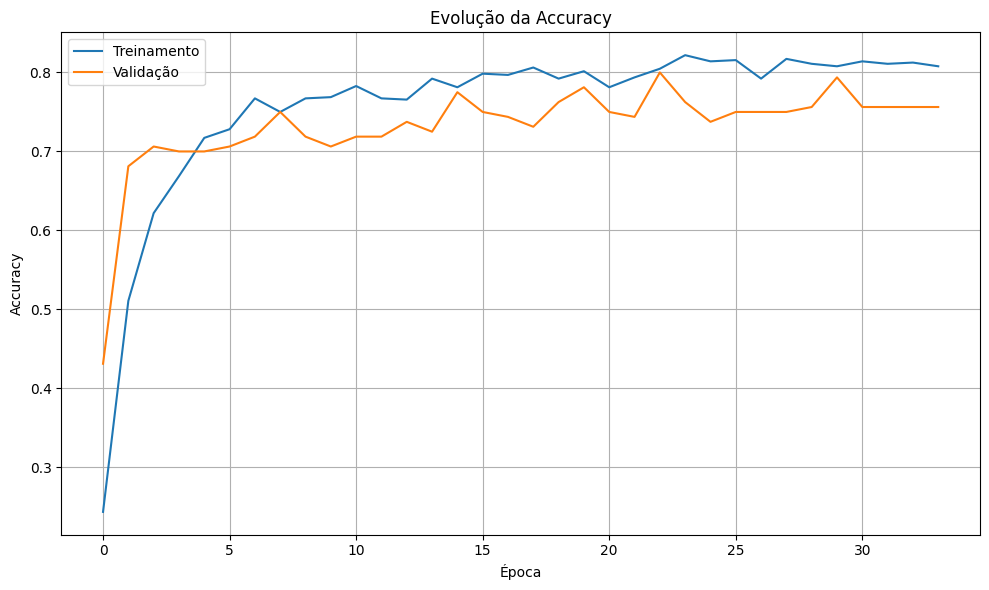

In [41]:
# ============================================================
# HISTÓRICO DA ACCURACY
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Treinamento"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validação"
)

plt.title("Evolução da Accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Histórico da loss

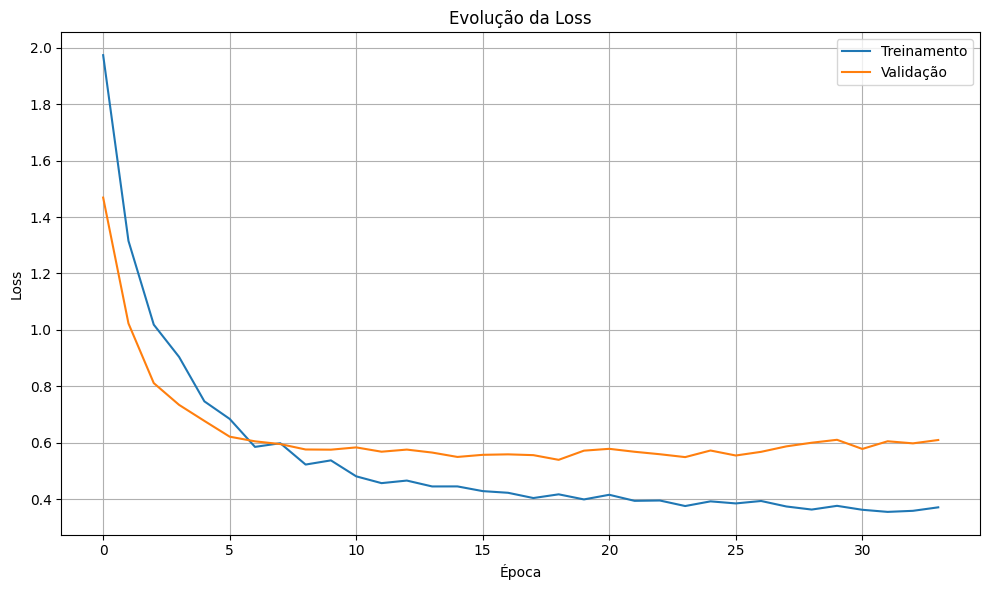

In [42]:
# ============================================================
# HISTÓRICO DA LOSS
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Treinamento"
)

plt.plot(
    history.history["val_loss"],
    label="Validação"
)

plt.title("Evolução da Loss")
plt.xlabel("Época")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Avaliação do modelo

In [43]:
# ============================================================
# AVALIAÇÃO
# ============================================================

test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("=" * 60)
print("RESULTADOS NO CONJUNTO DE TESTE")
print("=" * 60)

print(f"Loss:     {test_loss:.4f}")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Accuracy: {test_accuracy * 100:.2f}%")

RESULTADOS NO CONJUNTO DE TESTE
Loss:     0.3964
Accuracy: 0.8200
Accuracy: 82.00%


Predições

In [44]:
# ============================================================
# PREDIÇÕES
# ============================================================

y_probability = model.predict(
    X_test_scaled,
    verbose=0
)

y_pred = np.argmax(
    y_probability,
    axis=1
)

print("Predições realizadas.")

Predições realizadas.


Classification Report - Permite analisar precision, recall e F1-score por tipo de dispositivo.

In [45]:
# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

                 precision    recall  f1-score   support

             TV     0.9091    1.0000    0.9524        20
   baby_monitor     1.0000    1.0000    1.0000        20
         lights     0.0000    0.0000    0.0000        20
  motion_sensor     1.0000    0.9000    0.9474        20
security_camera     1.0000    1.0000    1.0000        20
 smoke_detector     1.0000    1.0000    1.0000        20
         socket     0.3654    0.9500    0.5278        20
     thermostat     1.0000    0.9500    0.9744        20
          watch     1.0000    0.9500    0.9744        20
   water_sensor     0.9000    0.4500    0.6000        20

       accuracy                         0.8200       200
      macro avg     0.8174    0.8200    0.7976       200
   weighted avg     0.8174    0.8200    0.7976       200



Matriz de confusão

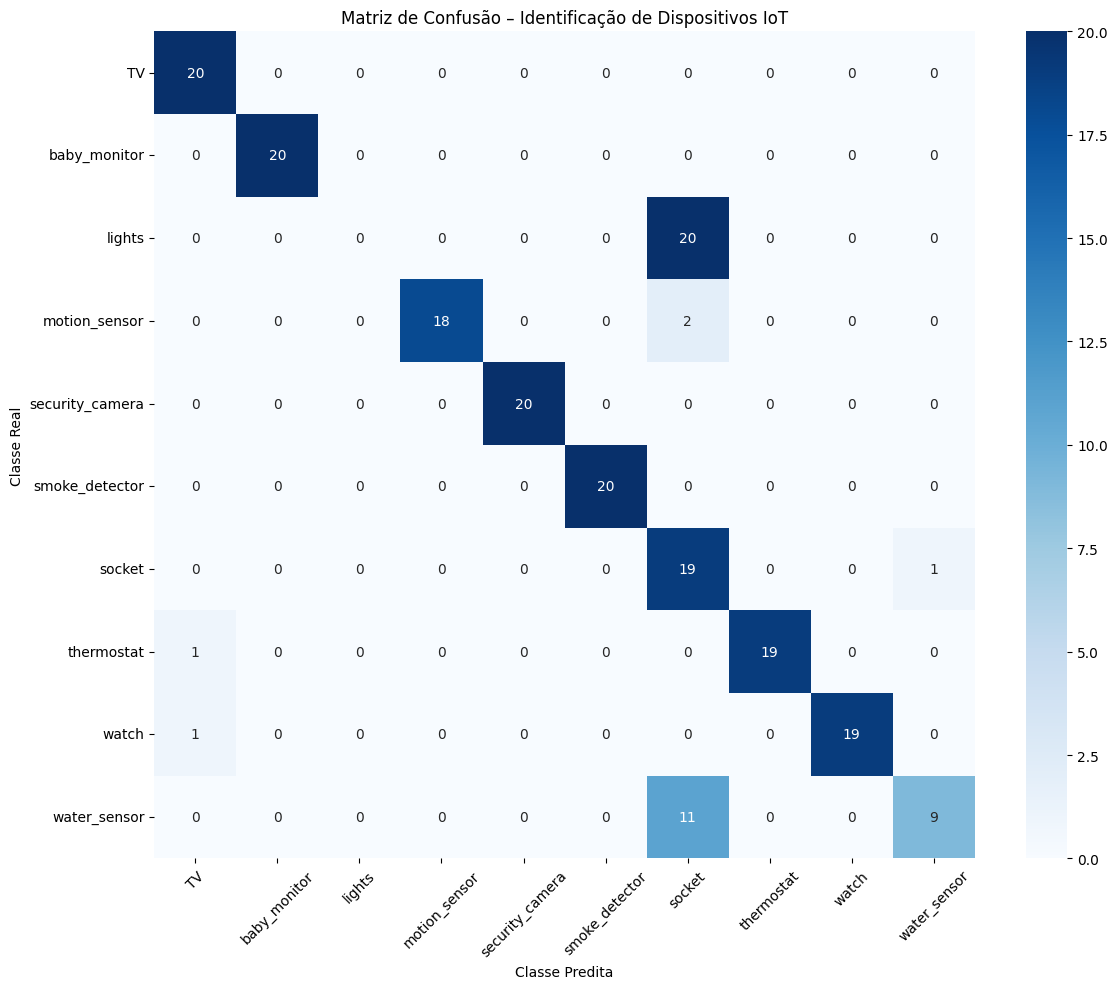

In [46]:
# ============================================================
# MATRIZ DE CONFUSÃO
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Matriz de Confusão – Identificação de Dispositivos IoT")

plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Accuracy por classe

In [47]:
# ============================================================
# DESEMPENHO POR CLASSE
# ============================================================

results = []

for i, class_name in enumerate(class_names):

    mask = y_test == i

    class_accuracy = np.mean(
        y_pred[mask] == y_test[mask]
    )

    results.append({
        "Dispositivo": class_name,
        "Accuracy": class_accuracy
    })

class_results = pd.DataFrame(results)

class_results["Accuracy (%)"] = (
    class_results["Accuracy"] * 100
)

display(
    class_results.sort_values(
        "Accuracy"
    )
)

,Dispositivo,Accuracy,Accuracy (%)
2,lights,0.00,0.0
9,water_sensor,0.45,45.0
3,motion_sensor,0.90,90.0
6,socket,0.95,95.0
8,watch,0.95,95.0
7,thermostat,0.95,95.0
0,TV,1.00,100.0
1,baby_monitor,1.00,100.0
4,security_camera,1.00,100.0
5,smoke_detector,1.00,100.0


Confiança das previsões

In [48]:
# ============================================================
# CONFIANÇA DAS PREDIÇÕES
# ============================================================

prediction_confidence = np.max(
    y_probability,
    axis=1
)

prediction_results = pd.DataFrame({
    "Classe_real": label_encoder.inverse_transform(y_test),
    "Classe_predita": label_encoder.inverse_transform(y_pred),
    "Confianca": prediction_confidence
})

prediction_results["Confianca (%)"] = (
    prediction_results["Confianca"] * 100
)

display(
    prediction_results.head(20)
)

,Classe_real,Classe_predita,Confianca,Confianca (%)
0,baby_monitor,baby_monitor,0.801674,80.167389
1,TV,TV,0.527569,52.756901
2,socket,socket,0.405413,40.541252
3,smoke_detector,smoke_detector,0.999401,99.940094
4,TV,TV,0.976445,97.644531
5,lights,socket,0.405352,40.535248
6,water_sensor,socket,0.401456,40.145622
7,lights,socket,0.405267,40.526737
8,security_camera,security_camera,0.994759,99.475906
9,smoke_detector,smoke_detector,0.997973,99.797264


Identificação de classificações incorretas

In [49]:
# ============================================================
# ERROS DE CLASSIFICAÇÃO
# ============================================================

errors = prediction_results[
    prediction_results["Classe_real"] !=
    prediction_results["Classe_predita"]
].copy()

print(
    f"Quantidade de classificações incorretas: "
    f"{len(errors)}"
)

print(
    f"Percentual de classificações incorretas: "
    f"{len(errors) / len(prediction_results) * 100:.2f}%"
)

display(
    errors.head(20)
)

Quantidade de classificações incorretas: 36
Percentual de classificações incorretas: 18.00%


,Classe_real,Classe_predita,Confianca,Confianca (%)
5,lights,socket,0.405352,40.535248
6,water_sensor,socket,0.401456,40.145622
7,lights,socket,0.405267,40.526737
15,motion_sensor,socket,0.403127,40.312679
18,motion_sensor,socket,0.397980,39.797993
19,water_sensor,socket,0.403237,40.323673
20,lights,socket,0.408325,40.832520
23,lights,socket,0.403186,40.318565
31,lights,socket,0.404012,40.401161
38,lights,socket,0.405077,40.507660


Simulação de identificação de um ativo

In [50]:
# ============================================================
# SIMULAÇÃO DE IDENTIFICAÇÃO DE UM ATIVO
# ============================================================

sample_index = 0

sample = X_test_scaled[
    sample_index
].reshape(1, -1)

probabilities = model.predict(
    sample,
    verbose=0
)[0]

predicted_class = np.argmax(
    probabilities
)

predicted_device = label_encoder.inverse_transform(
    [predicted_class]
)[0]

confidence = probabilities[
    predicted_class
]

real_device = label_encoder.inverse_transform(
    [y_test[sample_index]]
)[0]

print("=" * 70)
print("IDENTIFICAÇÃO DO ATIVO")
print("=" * 70)

print(f"Classe real:       {real_device}")
print(f"Classe predita:    {predicted_device}")
print(f"Confiança:         {confidence * 100:.2f}%")

if predicted_device == real_device:
    print("\nResultado: ✓ Dispositivo identificado corretamente.")
else:
    print("\nResultado: ⚠ Classificação divergente.")

IDENTIFICAÇÃO DO ATIVO
Classe real:       baby_monitor
Classe predita:    baby_monitor
Confiança:         80.17%

Resultado: ✓ Dispositivo identificado corretamente.


Top 3 possibilidades

In [51]:
# ============================================================
# TOP 3 CLASSIFICAÇÕES
# ============================================================

top_k = min(3, len(class_names))

top_indices = np.argsort(
    probabilities
)[::-1][:top_k]

print("=" * 70)
print("TOP CLASSIFICAÇÕES DO ATIVO")
print("=" * 70)

for position, index in enumerate(top_indices, start=1):

    device = class_names[index]
    probability = probabilities[index]

    print(
        f"{position}. "
        f"{device:25s} "
        f"{probability * 100:.2f}%"
    )

TOP CLASSIFICAÇÕES DO ATIVO
1. baby_monitor              80.17%
2. security_camera           11.07%
3. watch                     4.04%


Regra simples de apoio ao inventário

Aqui vamos tomar cuidado com a interpretação.

A rede neural não sabe se um dispositivo é autorizado. Ela apenas identifica o tipo.

Por isso, podemos simular um inventário autorizado.

In [52]:
# ============================================================
# INVENTÁRIO SIMULADO
# ============================================================

authorized_devices = [
    "lights",
    "motion_sensor",
    "security_camera",
    "thermostat"
]

print("Dispositivos autorizados no inventário:")
print("-" * 50)

for device in authorized_devices:
    print(device)

Dispositivos autorizados no inventário:
--------------------------------------------------
lights
motion_sensor
security_camera
thermostat


Verificação contra o inventário

In [53]:
# ============================================================
# VERIFICAÇÃO CONTRA O INVENTÁRIO
# ============================================================

print("=" * 70)
print("VERIFICAÇÃO DO ATIVO")
print("=" * 70)

print(f"Dispositivo identificado: {predicted_device}")
print(f"Confiança: {confidence * 100:.2f}%")

if predicted_device in authorized_devices:

    print("\n✓ O tipo de dispositivo está presente no inventário autorizado.")

else:

    print(
        "\n⚠ ALERTA: o tipo de dispositivo identificado "
        "não está no inventário autorizado."
    )

    print(
        "→ Recomenda-se investigação do ativo."
    )

VERIFICAÇÃO DO ATIVO
Dispositivo identificado: baby_monitor
Confiança: 80.17%

⚠ ALERTA: o tipo de dispositivo identificado não está no inventário autorizado.
→ Recomenda-se investigação do ativo.


## **OBS:** Isso representa apenas uma simulação conceitual. O material da disciplina destaca que um ativo fora do inventário deve ser investigado quanto à sua autorização e, conforme o caso, tratado/removido ou colocado em quarentena.

Salvar o modelo

In [54]:
# ============================================================
# SALVAMENTO DO MODELO
# ============================================================

MODEL_PATH = "/content/iot_device_neural_network.keras"

model.save(MODEL_PATH)

print("Modelo salvo em:")
print(MODEL_PATH)

Modelo salvo em:
/content/iot_device_neural_network.keras


Salvar o scaler

In [55]:
# ============================================================
# SALVAR PARAMETROS DE NORMALIZAÇÃO
# ============================================================

import joblib

SCALER_PATH = "/content/iot_device_scaler.pkl"

joblib.dump(
    scaler,
    SCALER_PATH
)

print("Scaler salvo em:")
print(SCALER_PATH)

Scaler salvo em:
/content/iot_device_scaler.pkl


Salvar o Label Encoder

In [56]:
# ============================================================
# SALVAR CODIFICADOR DAS CLASSES
# ============================================================

ENCODER_PATH = "/content/iot_device_label_encoder.pkl"

joblib.dump(
    label_encoder,
    ENCODER_PATH
)

print("Label encoder salvo em:")
print(ENCODER_PATH)

Label encoder salvo em:
/content/iot_device_label_encoder.pkl


Exportar resultados

In [57]:
# ============================================================
# EXPORTAÇÃO DOS RESULTADOS
# ============================================================

RESULTS_PATH = "/content/iot_prediction_results.csv"

prediction_results.to_csv(
    RESULTS_PATH,
    index=False
)

print("Resultados salvos em:")
print(RESULTS_PATH)

Resultados salvos em:
/content/iot_prediction_results.csv


Resumo final

In [58]:
# ============================================================
# RESUMO FINAL DO EXPERIMENTO
# ============================================================

print("=" * 80)
print("RESUMO DO EXPERIMENTO")
print("=" * 80)

print(f"Dataset:                  IoT Device Identification")
print(f"Variável alvo:            {TARGET}")
print(f"Número de classes:        {num_classes}")
print(f"Número de features:       {input_dim}")

print(f"\nAmostras treinamento:     {len(X_train)}")
print(f"Amostras teste:           {len(X_test)}")

print(f"\nLoss final:               {test_loss:.4f}")
print(f"Accuracy final:           {test_accuracy:.4f}")
print(f"Accuracy final:           {test_accuracy * 100:.2f}%")

print("\nClasses:")
for class_name in class_names:
    print(f" - {class_name}")

RESUMO DO EXPERIMENTO
Dataset:                  IoT Device Identification
Variável alvo:            device_category
Número de classes:        10
Número de features:       160

Amostras treinamento:     800
Amostras teste:           200

Loss final:               0.3964
Accuracy final:           0.8200
Accuracy final:           82.00%

Classes:
 - TV
 - baby_monitor
 - lights
 - motion_sensor
 - security_camera
 - smoke_detector
 - socket
 - thermostat
 - watch
 - water_sensor


**Conclusão**

# Conclusão

Este experimento demonstrou a aplicação de uma Rede Neural Artificial
para identificação de dispositivos IoT a partir de características
associadas ao tráfego de rede.

A abordagem foi estruturada como um problema de classificação
supervisionada, utilizando características do tráfego como entrada e a
categoria do dispositivo como variável de saída.

Do ponto de vista de Segurança Cibernética, a solução pode ser utilizada
como mecanismo auxiliar para descoberta e classificação de ativos.

A aplicação possui relação direta com o Controle 1 – Inventário e
Controle de Ativos Corporativos, uma vez que a identificação automática
de dispositivos pode contribuir para aumentar a visibilidade sobre os
ativos presentes na infraestrutura.

Entretanto, a classificação realizada pelo modelo não determina, por si
só, se um dispositivo é autorizado ou não. Essa decisão depende da
comparação com o inventário corporativo e dos processos de autorização,
investigação e tratamento definidos pela organização.

Como trabalhos futuros, podem ser avaliados:

1. otimização da arquitetura da rede neural;
2. seleção automática das características mais relevantes;
3. comparação com outros algoritmos de aprendizado de máquina;
4. utilização de validação cruzada;
5. tratamento de possíveis desequilíbrios entre classes;
6. identificação de dispositivos desconhecidos;
7. integração com inventários reais de ativos;
8. utilização de dados de tráfego capturados em ambiente real;
9. criação de um mecanismo de alerta para ativos não autorizados;
10. avaliação do modelo em dados diferentes daqueles utilizados no
   treinamento.